Code to generate Figure 3 subplots

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [19]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

Remove proteins with low plddt, are membrane proteins and/or signal peptide

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 50) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 3222


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01299; there are 332 hubs and 2890 non hubs


In [5]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Only remove inf/nan — DO NOT require > 0
ms_hub_vals    = ms_hubs["Villen_halflife_min"].replace([np.inf, -np.inf], np.nan).dropna()
ms_nothub_vals = ms_nothub["Villen_halflife_min"].replace([np.inf, -np.inf], np.nan).dropna()
#y2h_nothub_vals = y2h_nothub["Ghosh-Dill-dG"]
#y2h_hub_vals    = y2h_hubs["Ghosh-Dill-dG"]

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|█| 1000000/1000000 [00:15<00:00, 6391


MS hubs: median=91.20, 95% CI=(90.00, 92.40), n=291)


Bootstrapping medians: 100%|█| 1000000/1000000 [00:32<00:00, 3068

MS non-hubs: median=133.20, 95% CI=(130.20, 136.20), n=2006)


In [6]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS hubs vs MS non-hubs
n(hubs) = 291, n(non-hubs) = 2006
median(hubs) = 91.20, median(non-hubs) = 133.20
U = 160210.50, p = 1.35e-35


/tmp/ipykernel_4001/842702599.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not

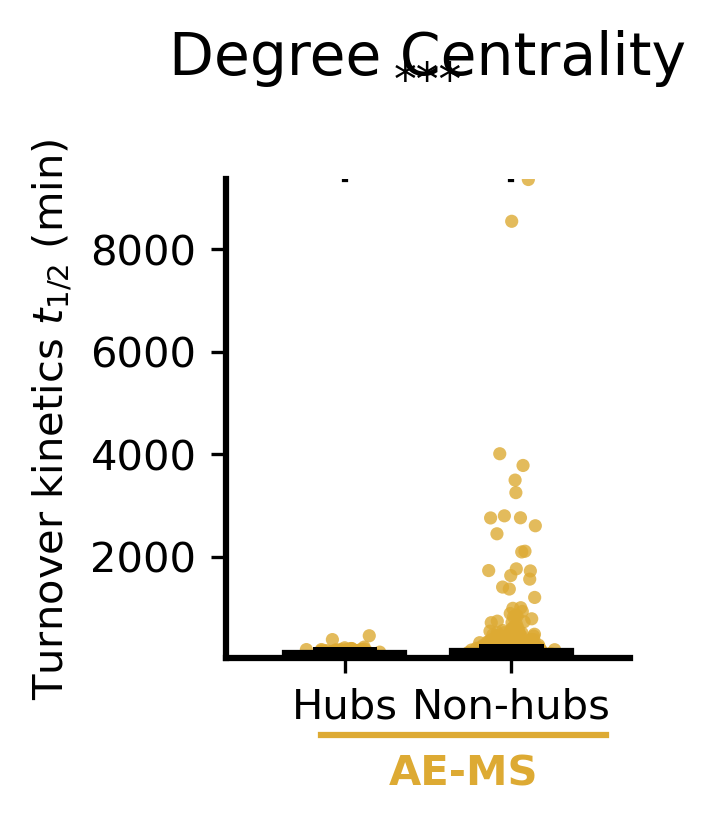

In [7]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non\u2011hubs"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel(r"Turnover kinetics $t_{1/2}$ (min)")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = max(ms_hub_vals.max(), ms_nothub_vals.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS group label under x-axis
ax.plot(
    [0.9, 2.1], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.5, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}5b-1.svg")
plt.show()

In [16]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

def calculate_hub_stability_correlations(df, hub_threshold_quantile=0.90):
    print("="*90)
    print("CORRELATION ANALYSIS: Degree Centrality Hubs (MS/IPMS) vs Protein Stability")
    print("="*90)

    # Prepare full dataset
    base_cols = ['degree_centrality', 'Villen_halflife_min']
    stability_info = [
        ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG'),
        ('cagiada-dG', 'Cagiada ΔG'),
        ('Rosetta_best_total_score', 'Rosetta Total Score'),
    ]

    # Special handling for meltome
    meltome_data = df[df['meltome-fit-R2'] >= 0.9].copy()
    if len(meltome_data) > 10:
        stability_info.append(('meltome-melting-point', 'Meltome Melting Point (°C)'))
        print(f"Meltome data (R² ≥ 0.9): {len(meltome_data)} proteins")
    else:
        print("Warning: Not enough high-quality meltome data (R² ≥ 0.9)")

    # Full data + hubs
    data = df[base_cols + [col for col, _ in stability_info]].dropna(subset=base_cols)
    hubs = data[data['degree_centrality'] >= data['degree_centrality'].quantile(hub_threshold_quantile)]

    print(f"\nTotal proteins with half-life: {len(data)}")
    print(f"Degree hubs (top 10%): {len(hubs)}")

    for stab_col, stab_name in stability_info:
        if stab_col not in data.columns:
            print(f"\nSkipping {stab_name} (column missing)")
            continue

        # Use filtered meltome only if it's that metric
        if stab_col == 'meltome-melting-point':
            current_data = meltome_data[[stab_col, 'Villen_halflife_min']].dropna()
            current_hubs = hubs[hubs.index.isin(meltome_data.index)]
        else:
            current_data = data[['Villen_halflife_min', stab_col]].dropna()
            current_hubs = hubs[[ 'Villen_halflife_min', stab_col]].dropna()

        print(f"\n→ {stab_name}")
        print(f"   n (all) = {len(current_data)}, n (hubs) = {len(current_hubs)}")

        # Spearman
        rho, p = spearmanr(current_data['Villen_halflife_min'], current_data[stab_col])
        print(f"   Spearman (all):  ρ = {rho:+.3f}, p = {p:.2g}")

        if len(current_hubs) > 5:
            rho_h, p_h = spearmanr(current_hubs['Villen_halflife_min'], current_hubs[stab_col])
            print(f"   Spearman (hubs): ρ = {rho_h:+.3f}, p = {p_h:.2g}")
        
        # Pearson on log(t½)
        log_t12 = np.log10(current_data['Villen_halflife_min'])
        r, p = pearsonr(log_t12, current_data[stab_col])
        print(f"   Pearson log(t½) (all):  r = {r:+.3f}, p = {p:.2g}")

        if len(current_hubs) > 5:
            log_t12_h = np.log10(current_hubs['Villen_halflife_min'])
            r_h, p_h = pearsonr(log_t12_h, current_hubs[stab_col])
            print(f"   Pearson log(t½) (hubs): r = {r_h:+.3f}, p = {p_h:.2g}")

# RUN IT
calculate_hub_stability_correlations(filtered_nodes, hub_threshold_quantile=0.90)

CORRELATION ANALYSIS: Degree Centrality Hubs (MS/IPMS) vs Protein Stability
Meltome data (R² ≥ 0.9): 1598 proteins

Total proteins with half-life: 2297
Degree hubs (top 10%): 232

→ Ghosh-Dill ΔG
   n (all) = 2296, n (hubs) = 232
   Spearman (all):  ρ = +0.017, p = 0.43
   Spearman (hubs): ρ = +0.343, p = 8.2e-08
   Pearson log(t½) (all):  r = -0.006, p = 0.78
   Pearson log(t½) (hubs): r = +0.241, p = 0.00021

→ Cagiada ΔG
   n (all) = 2296, n (hubs) = 232
   Spearman (all):  ρ = +0.071, p = 0.00066
   Spearman (hubs): ρ = -0.247, p = 0.00015
   Pearson log(t½) (all):  r = +0.091, p = 1.4e-05
   Pearson log(t½) (hubs): r = -0.179, p = 0.0063

→ Rosetta Total Score
   n (all) = 2296, n (hubs) = 232
   Spearman (all):  ρ = -0.042, p = 0.042
   Spearman (hubs): ρ = +0.296, p = 4.4e-06
   Pearson log(t½) (all):  r = -0.018, p = 0.39
   Pearson log(t½) (hubs): r = +0.189, p = 0.0038

→ Meltome Melting Point (°C)
   n (all) = 1385, n (hubs) = 170
   Spearman (all):  ρ = +0.218, p = 2.4e-16


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

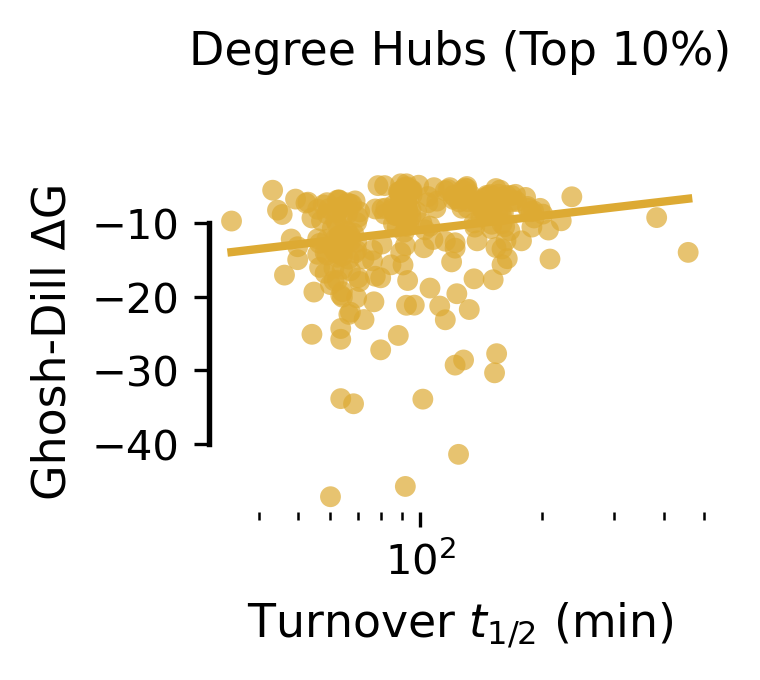

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

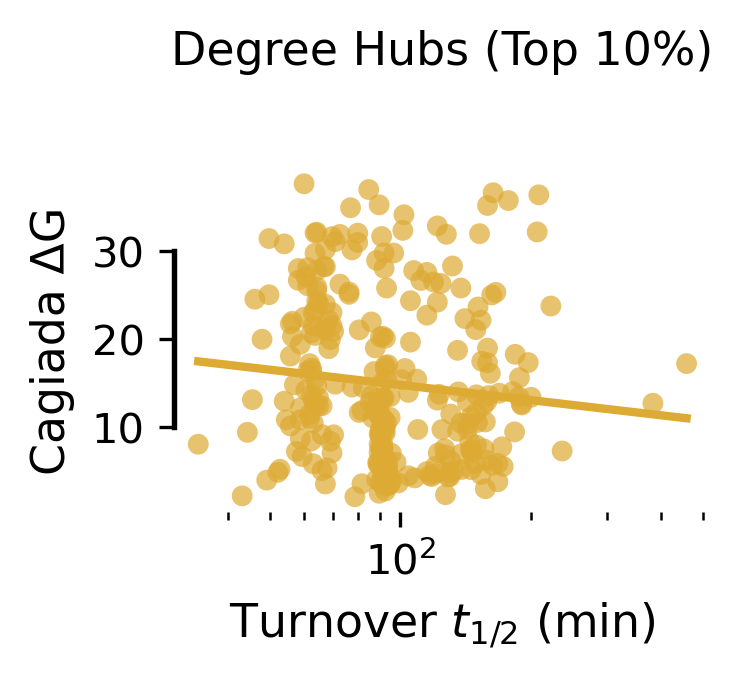

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


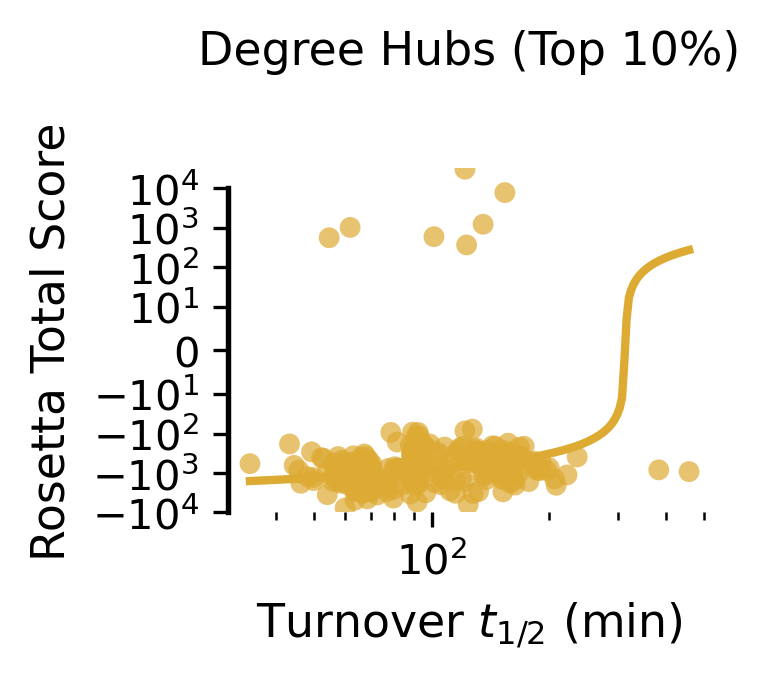

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

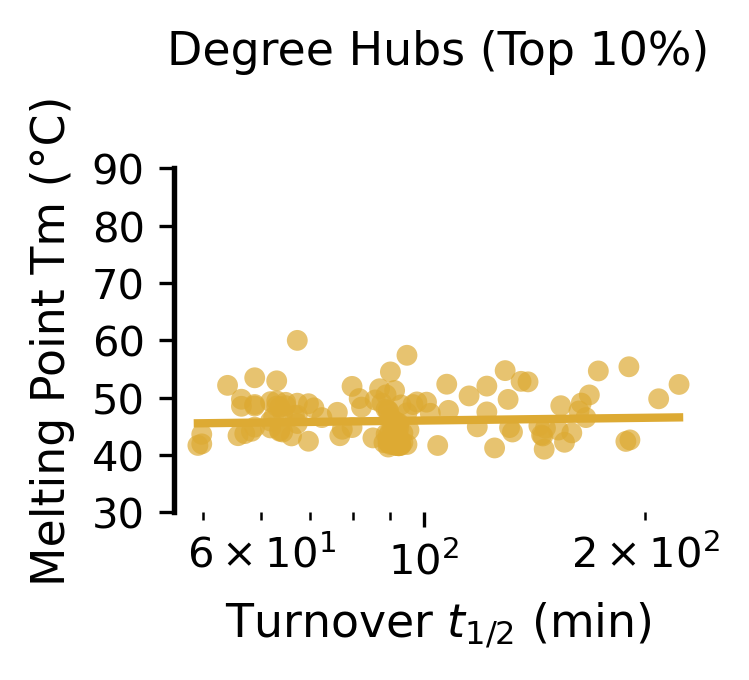

In [18]:
def plot_hub_scatter(ax, data, x, y, ylabel, title, is_rosetta=False, is_meltome=False):
    hubs = data[data['degree_centrality'] >= data['degree_centrality'].quantile(0.9)]

    sns.scatterplot(data=hubs, x=x, y=y, color=color_ms, s=25, alpha=0.7, ax=ax, edgecolor='none')

    if len(hubs) > 3:
        sns.regplot(data=hubs, x=x, y=y, scatter=False, logx=True,
                    color=color_ms, ci=None, line_kws={'lw': 2}, ax=ax)

    ax.set_xscale('log')
    ax.set_xlabel(r'Turnover $t_{1/2}$ (min)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if is_rosetta:
        ax.set_yscale('symlog', linthresh=10)
        ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
    if is_meltome:
        ax.set_ylim(30, 90)

    sns.despine(ax=ax, trim=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)

# Prepare data
plot_data = filtered_nodes.copy()

# Filter meltome strictly
meltome_hq = plot_data[plot_data['meltome-fit-R2'] >= 0.9]

# 1. Individual high-res SVGs
fig_counter = 1
stability_list = [
    ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG', False),
    ('cagiada-dG', 'Cagiada ΔG', False),
    ('Rosetta_best_total_score', 'Rosetta Total Score', True),
    ('meltome-melting-point', 'Melting Point Tm (°C)', False, meltome_hq),
]

for item in stability_list:
    if len(item) == 4:
        col, name, is_rosetta, custom_data = item
    else:
        col, name, is_rosetta = item
        custom_data = plot_data

    fig, ax = plt.subplots(figsize=(2.6, 2.4))
    plot_hub_scatter(ax, custom_data, 'Villen_halflife_min', col, name,
                     'Degree Hubs (Top 10%)', is_rosetta=is_rosetta, is_meltome=('meltome' in col))
    plt.tight_layout()
    fig.savefig(f"{OUT_PATH}5B.{fig_counter}.svg", dpi=300, bbox_inches='tight')
    plt.show()

In [22]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=42):
    """
    Nonparametric bootstrap CI for the median
    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=np.float32)
    
    for b in trange(B, desc="Bootstrapping medians", leave=False):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)
    
    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

In [23]:
# Define MS degree hubs (top 10%)
ms_hubs = filtered_nodes[
    filtered_nodes['degree_centrality'] >= filtered_nodes['degree_centrality'].quantile(0.9)
].copy()

# Ensure boolean
ms_hubs['in_complex'] = ms_hubs['in_complex'].astype(bool)

# Split into Static (in complex) vs Dynamic (not in complex)
static_vals = ms_hubs[ms_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()
dynamic_vals = ms_hubs[~ms_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups for plotting
groups = [
    ("Static", static_vals, "#EECC66"),      # light gold
    ("Dynamic", dynamic_vals, "#997700"),    # dark gold
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups:
    print(f"{label:8}: n = {len(vals)}")

# Bootstrapped medians
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []
for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:8}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='two-sided')
print("\n=== Mann–Whitney U test (Static vs Dynamic hubs) ===")
print(f"n(Static) = {len(static_vals)}, n(Dynamic) = {len(dynamic_vals)}")
print(f"median(Static) = {np.median(static_vals):.1f}, median(Dynamic) = {np.median(dynamic_vals):.1f}")
print(f"U = {u_stat:.1f}, p = {p_val:.2g}")
stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
print(f"Significance: {stars}")

=== Protein counts in Degree Hubs (MS) ===
Static  : n = 157
Dynamic : n = 134

=== Bootstrapped median half-life (95% CI) ===


Static  : median = 94.8 min, 95% CI = (91.2, 118.2)


Dynamic : median = 90.0 min, 95% CI = (89.4, 91.2)

=== Mann–Whitney U test (Static vs Dynamic hubs) ===
n(Static) = 157, n(Dynamic) = 134
median(Static) = 94.8, median(Dynamic) = 90.0
U = 13135.0, p = 0.00026
Significance: ***


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

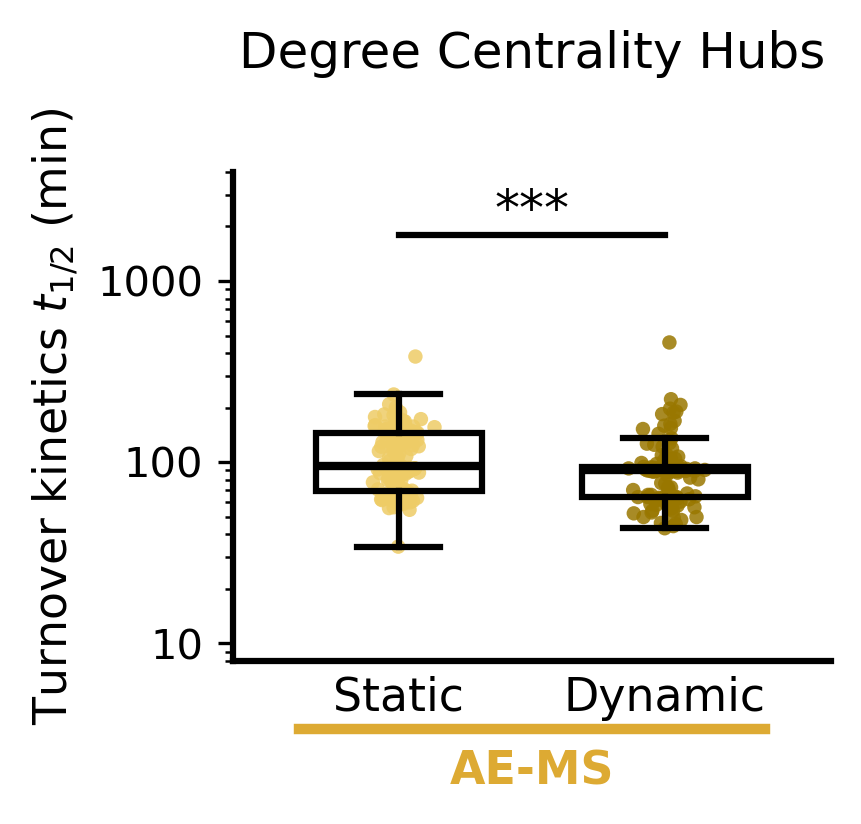

In [31]:
def add_bracket_with_text(ax, x1, x2, y, text, y_offset=3):
    y_top = y + y_offset
    ax.plot([x1, x1, x2, x2], [y, y_top, y_top, y], lw=1.5, c="black", clip_on=False)
    ax.text((x1 + x2)/2, y_top + 1.5, text, ha="center", va="bottom", fontsize=12)

# Prepare plot
fig, ax = plt.subplots(figsize=(3, 3))

positions = [1.0, 1.8]
group_data = [static_vals, dynamic_vals]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# Scatter (jittered)
for pos, vals, color in zip(positions, group_data, group_colors):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x_jitter, vals, s=12, color=color, alpha=0.85, edgecolor="none", zorder=2)

# Boxplot (outline only, no fill)
bp = ax.boxplot(
    group_data,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
    boxprops=dict(facecolor="none", edgecolor="black", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    zorder=3
)

# Styling
ax.set_yscale('log')
ax.set_ylim(8, 4000)
ax.set_yticks([10, 100, 1000])
ax.set_yticklabels(['10', '100', '1000'])
ax.set_ylabel(r'Turnover kinetics $t_{1/2}$ (min)', fontsize=11)
ax.set_title("Degree Centrality Hubs", fontsize=12)
ax.set_xticks(positions)
ax.set_xticklabels(["Static", "Dynamic"], fontsize=11)
ax.tick_params(axis='x', length=0)

# Spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

# Significance bracket
add_bracket_with_text(ax, positions[0], positions[1], y=1800, text=stars)

# Bottom group label: "AE-MS" style
trans = ax.get_xaxis_transform()
ax.plot([0.7, 2.1], [-0.14, -0.14], transform=trans, clip_on=False, color=MS_COLOR, lw=2.5)
ax.text(1.4, -0.18, "AE-MS", transform=trans, ha="center", va="top",
        fontsize=11, fontweight="bold", color=MS_COLOR)

plt.tight_layout()
plt.savefig(f"{OUT_PATH}Figure_5C.svg", dpi=400, bbox_inches='tight')
plt.savefig(f"{OUT_PATH}Figure_5C.pdf", dpi=400, bbox_inches='tight')
plt.show()

In [33]:
import numpy as np
from tqdm import trange

def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=42):
    """Your exact style: loop + trange, 1e6 resamples"""
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=np.float32)
    
    for b in trange(B, desc="Bootstrapping medians", leave=False):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)
    
    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

# === Prepare MS Degree Hubs (top 10%) ===
ms_hubs = filtered_nodes[
    filtered_nodes['degree_centrality'] >= filtered_nodes['degree_centrality'].quantile(0.9)
].copy()
ms_hubs['in_complex'] = ms_hubs['in_complex'].astype(bool)

# === Define the 4 stability metrics ===
stability_list = [
    ('Ghosh-Dill-dG',           'Ghosh-Dill ΔG',              False),
    ('cagiada-dG',              'Cagiada ΔG',                 False),
    ('Rosetta_best_total_score','Rosetta Total Score',        True),   # symlog
    ('meltome-melting-point',   'Meltome Melting Point (°C)', False),
]

# === Extract clean values: Static vs Dynamic hubs ===
groups = []
for col, name, is_rosetta in stability_list:
    if col == 'meltome-melting-point':
        # High-quality meltome only
        data = ms_hubs[ms_hubs['meltome-fit-R2'] >= 0.9]
    else:
        data = ms_hubs
    
    static_vals  = data[data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    dynamic_vals = data[~data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    
    groups.append((name, static_vals, dynamic_vals, is_rosetta))

print("=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Degree Hubs ===\n")
for name, static_vals, dynamic_vals, _ in groups:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data")
        continue
    m_s, lo_s, hi_s = bootstrap_ci_median(static_vals, random_state=42)
    m_d, lo_d, hi_d = bootstrap_ci_median(dynamic_vals, random_state=42)
    print(f"{name:30} | Static:  {m_s:6.2f} [{lo_s:.1f}, {hi_s:.1f}]  (n={len(static_vals)})")
    print(f"{'':30} | Dynamic: {m_d:6.2f} [{lo_d:.1f}, {hi_d:.1f}]  (n={len(dynamic_vals)})\n")

=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Degree Hubs ===



Ghosh-Dill ΔG                  | Static:   -8.86 [-10.1, -8.2]  (n=173)
                               | Dynamic:  -7.97 [-8.2, -7.2]  (n=159)



Cagiada ΔG                     | Static:   13.07 [11.1, 14.7]  (n=173)
                               | Dynamic:  10.49 [9.5, 12.7]  (n=159)



Rosetta Total Score            | Static:  -701.68 [-783.8, -606.5]  (n=173)
                               | Dynamic: -625.73 [-702.4, -553.4]  (n=159)



Meltome Melting Point (°C)     | Static:   47.14 [45.3, 48.0]  (n=112)
                               | Dynamic:  44.12 [43.4, 45.1]  (n=122)



In [34]:
from scipy.stats import mannwhitneyu

print("\n=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===\n")

results = []
for name, static_vals, dynamic_vals, _ in groups:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data for test")
        results.append((name, np.nan, 1.0))
        continue
    
    u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='two-sided')
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    
    print(f"{name:30} | U = {u_stat:6.0f}, p = {p_val:.2g} {stars}")
    print(f"{'':32} Static median = {np.median(static_vals):.2f}, Dynamic = {np.median(dynamic_vals):.2f}\n")
    
    results.append((name, u_stat, p_val))


=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===

Ghosh-Dill ΔG                  | U =  11638, p = 0.016 *
                                 Static median = -8.86, Dynamic = -7.97

Cagiada ΔG                     | U =  15169, p = 0.11 ns
                                 Static median = 13.07, Dynamic = 10.49

Rosetta Total Score            | U =  12865, p = 0.31 ns
                                 Static median = -701.68, Dynamic = -625.73

Meltome Melting Point (°C)     | U =   8438, p = 0.0019 **
                                 Static median = 47.14, Dynamic = 44.12



/tmp/ipykernel_4001/454194882.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
/tmp/ipykernel_4001/454194882.py:97: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
findfont: Fo

Saved: figures/5D.1.svg


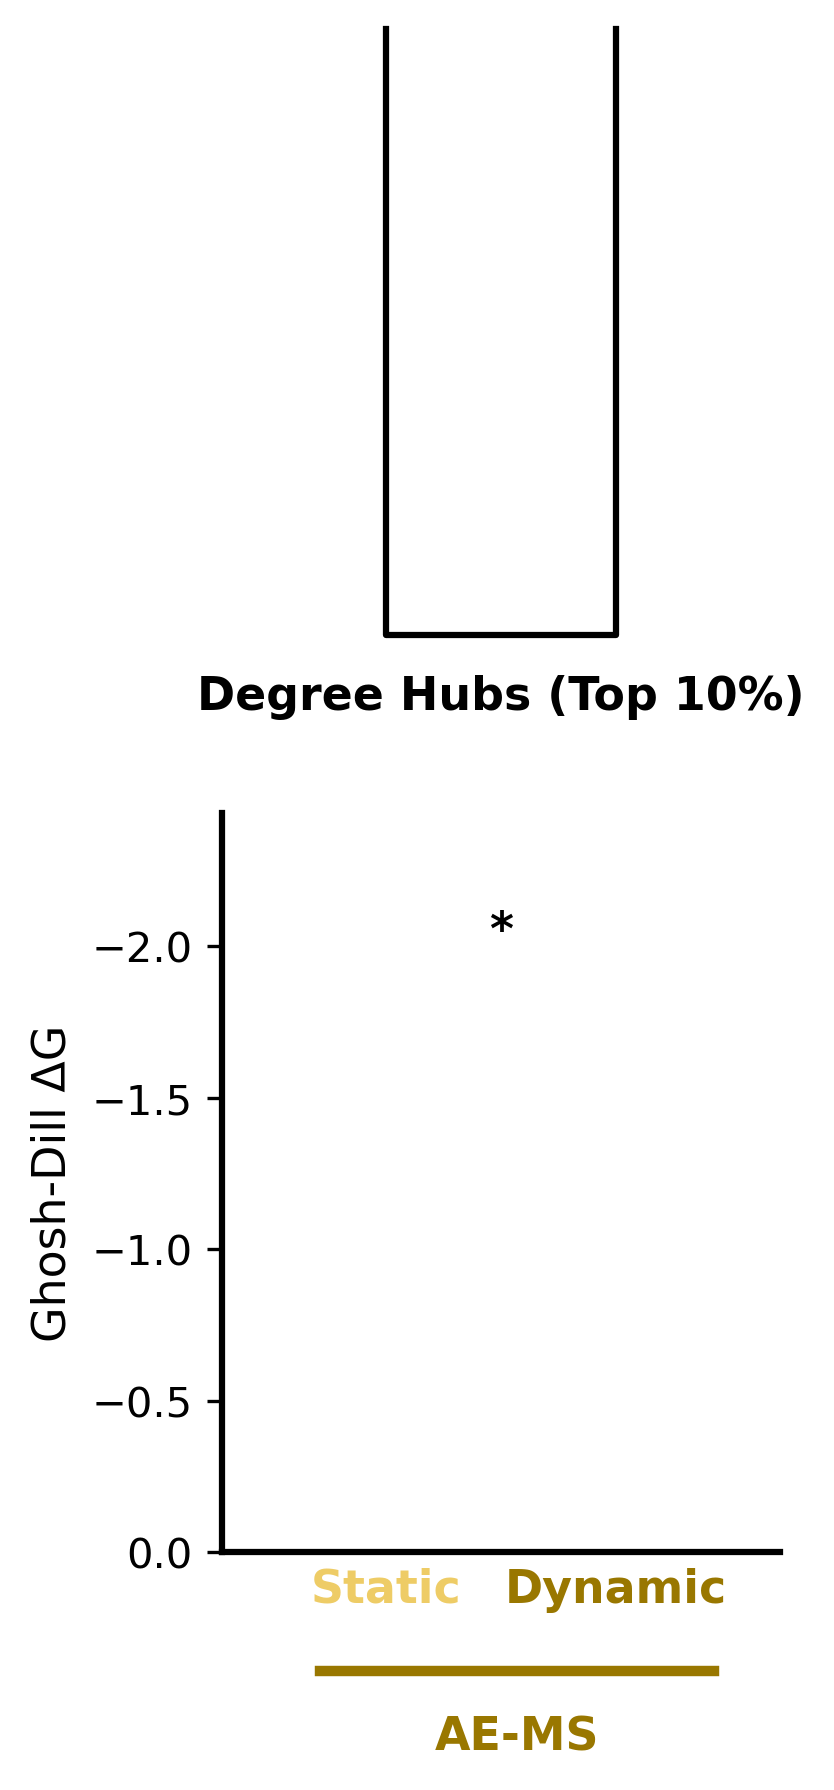

/tmp/ipykernel_4001/454194882.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not fou

Saved: figures/5D.2.svg


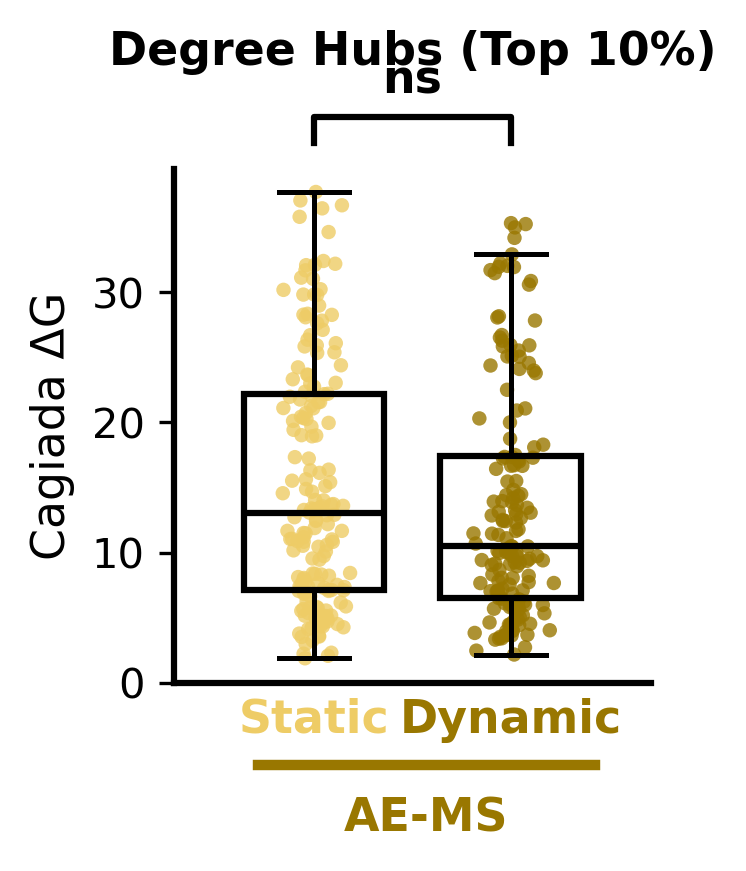

/tmp/ipykernel_4001/454194882.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not fou

Saved: figures/5D.3.svg


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


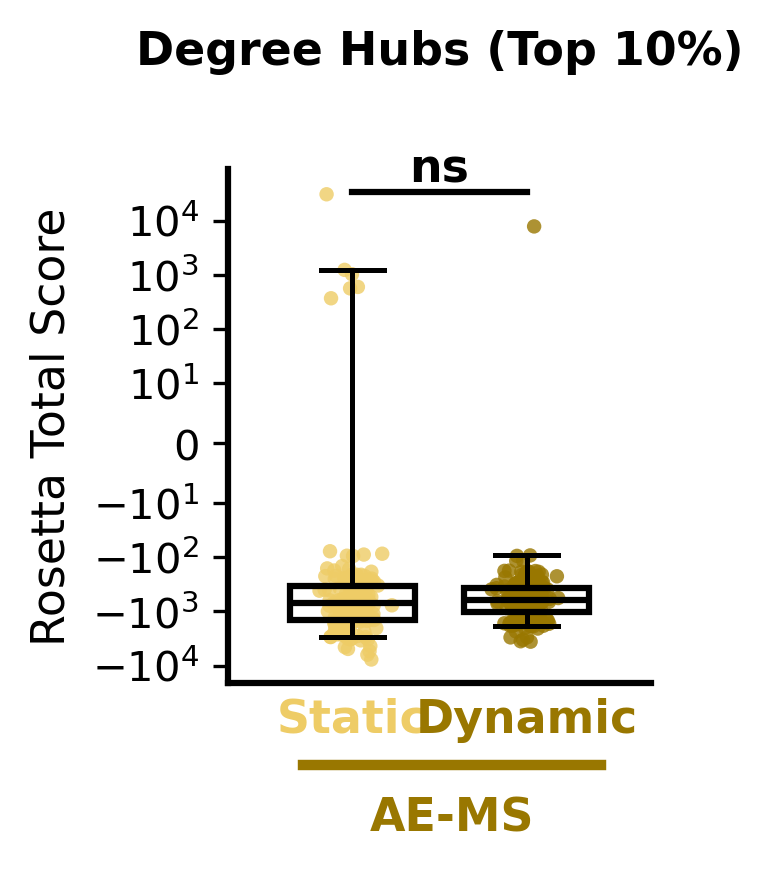

/tmp/ipykernel_4001/454194882.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not fou

Saved: figures/5D.4.svg


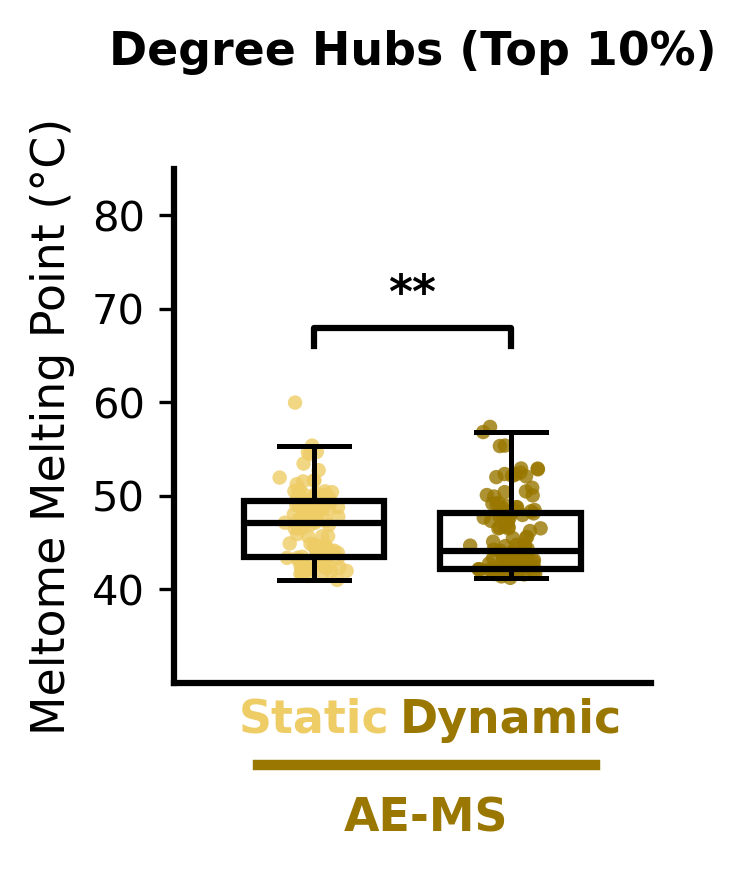

In [36]:
# ==================== PART 3: PLOTTING – INDIVIDUAL FIGURES (Your Exact Style) ====================

import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch

os.makedirs(OUT_PATH, exist_ok=True)

# Colors – exactly like your 5C and meltome plots
COLOR_STATIC  = "#EECC66"   # light gold
COLOR_DYNAMIC = "#997700"   # dark gold

def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 2.0
    ax.plot([x1, x1, x2, x2], [y, y_top, y_top, y], lw=1.5, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y_top + 1.05, text, ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# Re-use the same groups from Part 1 & 2
# (they already contain clean static_vals, dynamic_vals, name, is_rosetta)

figure_counter = 1

for idx, (stab_name, static_vals, dynamic_vals, is_rosetta) in enumerate(groups, 1):
    # Skip if not enough data
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"Skipping {stab_name} – not enough data")
        continue

    fig, ax = plt.subplots(figsize=(2.4, 3.2))

    # --- 1. Jittered scatter (lower zorder) ---
    positions = [1.0, 1.7]
    for pos, vals, color in zip(positions, [static_vals, dynamic_vals], [COLOR_STATIC, COLOR_DYNAMIC]):
        x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
        ax.scatter(x_jitter, vals, s=12, alpha=0.8, color=color, edgecolor="none", zorder=2)

    # --- 2. Boxplot: outline only, no fill, no fliers ---
    bp = ax.boxplot(
        [static_vals.values, dynamic_vals.values],
        positions=positions,
        labels=["Static", "Dynamic"],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        zorder=3
    )
    for box in bp["boxes"]:
        box.set_facecolor("none")
        box.set_edgecolor("black")
        box.set_linewidth(1.5)
    for element in ["whiskers", "caps", "medians"]:
        plt.setp(bp[element], color="black", linewidth=1.5 if element == "medians" else 1.2)

    # --- 3. Axis styling ---
    ax.set_ylabel(stab_name, fontsize=11)        # ← exactly your original y-label
    ax.set_title("Degree Hubs (Top 10%)", fontsize=11, fontweight="bold")

    # Special scaling
    if is_rosetta:  # Rosetta
        ax.set_yscale("symlog", linthresh=10)
        ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
    elif "Meltome" in stab_name:
        ax.set_ylim(30, 85)
        ax.set_yticks([40, 50, 60, 70, 80])
    else:
        ax.set_ylim(bottom=0)

    # X-axis: clean, bold, colored
    ax.set_xticks(positions)
    ax.set_xticklabels(["Static", "Dynamic"], fontsize=11, fontweight="bold")
    ax.tick_params(axis='x', length=0)
    labels = ax.get_xticklabels()
    labels[0].set_color(COLOR_STATIC)
    labels[1].set_color(COLOR_DYNAMIC)

    # Spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    # --- 4. Significance bracket ---
    p_val = [r[2] for r in results if stab_name in r[0]][0]  # get p from Part 2
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    y_bracket = 66 if "Meltome" in stab_name else np.max([np.max(static_vals), np.max(dynamic_vals)]) * 1.1
    add_bracket_with_text(ax, positions[0], positions[1], y_bracket, stars)

    # --- 5. Bottom bar + "AE-MS" label ---
    trans = ax.get_xaxis_transform()
    ax.plot([0.8, 2.0], [-0.16, -0.16], transform=trans, clip_on=False,
            color=COLOR_DYNAMIC, lw=2.5)
    ax.text(1.4, -0.22, "AE-MS", transform=trans, ha="center", va="top",
            fontsize=11, fontweight="bold", color=COLOR_DYNAMIC)

    plt.tight_layout()

    # --- Save individual SVG ---
    save_path = f"{OUT_PATH}5D.{figure_counter}.svg"
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    print(f"Saved: {save_path}")
    figure_counter += 1

    plt.show()  # optional: set to plt.close() if running in batch